# Exp 3 — Architecture Comparison

**Goal:** Put the Exp 3 architecture ranking and learning curves into one Colab notebook, following the same reporting style as `02_fusion.ipynb`.

This notebook reads the files in `results/exp3_architecture`, rebuilds the ranking table from `*_metrics.json`, and displays / regenerates the learning-curve figures from `*_history.csv`.

Expected flat-file format in the folder:

- `no_graph_metrics.json`
- `fixed_fused_alpha_0.5_metrics.json`
- `chebnet_fused_metrics.json`, `chebnet_fused_history.csv`
- `graphsage_fused_metrics.json`, `graphsage_fused_history.csv`
- `gat_fused_metrics.json`, `gat_fused_history.csv`
- optional: `exp3_architecture_ranking.csv`, `exp3_learning_curve_train_loss.png`, `exp3_learning_curve_val_ndcg20.png`

## 0. Setup

Use the same basic libraries as the Exp 2 notebook: `os`, `sys`, `json`, `pandas`, and `IPython.display`.  
For learning curves, this notebook also uses `matplotlib.pyplot`, as in your current learning-curve script.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


RESULTS_DIR = Path("/content/drive/MyDrive/results/exp3_architecture")

print("RESULTS_DIR:", RESULTS_DIR)
print("exists     :", RESULTS_DIR.exists())

if not RESULTS_DIR.exists():
    print("\nFolder not found. Searching under /content/drive/MyDrive ...")
    matches = list(Path("/content/drive/MyDrive").rglob("exp3_architecture"))

    if len(matches) == 0:
        raise FileNotFoundError(
            "Cannot find exp3_architecture folder. "
            "Please check whether it is really under My Drive."
        )
    else:
        RESULTS_DIR = matches[0]
        print("Found folder:", RESULTS_DIR)

BASE = RESULTS_DIR
FIG_DIR = BASE

print("\nFiles in folder:")
for f in sorted(BASE.iterdir()):
    print(" -", f.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RESULTS_DIR: /content/drive/MyDrive/results/exp3_architecture
exists     : True

Files in folder:
 - chebnet_fused_history.csv
 - chebnet_fused_metrics.json
 - exp3_architecture_ranking.csv
 - exp3_learning_curve_train_loss.png
 - exp3_learning_curve_val_ndcg20.png
 - fixed_fused_alpha_0.5_metrics.json
 - gat_fused_history.csv
 - gat_fused_metrics.json
 - graphsage_fused_history.csv
 - graphsage_fused_metrics.json
 - no_graph_metrics.json


## 1. Check files in the Exp 3 folder

In [5]:
files = sorted([p.name for p in BASE.iterdir() if p.is_file()])
print('Files found in Exp 3 folder:')
print('-' * 60)
for name in files:
    print(name)

expected = [
    'no_graph_metrics.json',
    'fixed_fused_alpha_0.5_metrics.json',
    'chebnet_fused_metrics.json',
    'chebnet_fused_history.csv',
    'graphsage_fused_metrics.json',
    'graphsage_fused_history.csv',
    'gat_fused_metrics.json',
    'gat_fused_history.csv',
]

missing = [x for x in expected if not (BASE / x).exists()]
if missing:
    print('\n[WARN] Missing expected flat files:')
    for x in missing:
        print('  -', x)
else:
    print('\nAll expected flat files are present.')

Files found in Exp 3 folder:
------------------------------------------------------------
chebnet_fused_history.csv
chebnet_fused_metrics.json
exp3_architecture_ranking.csv
exp3_learning_curve_train_loss.png
exp3_learning_curve_val_ndcg20.png
fixed_fused_alpha_0.5_metrics.json
gat_fused_history.csv
gat_fused_metrics.json
graphsage_fused_history.csv
graphsage_fused_metrics.json
no_graph_metrics.json

All expected flat files are present.


## 2. Helper functions

These helpers support both possible layouts:

1. **Flat layout** from your screenshot: `chebnet_fused_metrics.json`, `chebnet_fused_history.csv` directly inside `exp3_architecture`.
2. **Nested layout** from the original scripts: `chebnet_fused/metrics.json`, `chebnet_fused/training_history.csv`.

In [6]:
RUNS = [
    {'label': 'MLP (no graph)',        'run': 'no_graph',                'has_history': False},
    {'label': 'GCN (fused α=0.5)',     'run': 'fixed_fused_alpha_0.5',   'has_history': True},
    {'label': 'ChebNet',               'run': 'chebnet_fused',           'has_history': True},
    {'label': 'GraphSAGE',             'run': 'graphsage_fused',         'has_history': True},
    {'label': 'GAT',                   'run': 'gat_fused',               'has_history': True},
]

RUN_LABEL = {r['run']: r['label'] for r in RUNS}


def first_existing(paths):
    """Return the first existing Path, otherwise None."""
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None


def metric_file(run):
    return first_existing([
        BASE / f'{run}_metrics.json',
        BASE / run / 'metrics.json',
    ])


def history_file(run):
    return first_existing([
        BASE / f'{run}_history.csv',
        BASE / run / 'training_history.csv',
        BASE / run / 'history.csv',
    ])


def get_any(d, keys, default=None):
    """Read the first available key from a metrics dictionary."""
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default


def find_col(cols, include_keywords):
    """Find a column whose lower-case name contains all keywords."""
    cols = list(cols)
    for c in cols:
        lc = str(c).lower()
        if all(k.lower() in lc for k in include_keywords):
            return c
    return None


def find_first_col(cols, keyword_groups):
    """Try several keyword groups and return the first matching column."""
    for kws in keyword_groups:
        c = find_col(cols, kws)
        if c is not None:
            return c
    return None


def as_float(x):
    if x is None:
        return None
    try:
        return float(x)
    except Exception:
        return None


def fmt_metric(x, digits=6):
    x = as_float(x)
    if x is None:
        return '—'
    return f'{x:.{digits}f}'


def fmt_pct(x):
    x = as_float(x)
    if x is None:
        return '—'
    return f'{x:+.1f} %'

## 3. Architecture ranking table

This recreates `exp3_architecture_ranking.csv` from the model metric JSON files.

In [7]:
rows = []

for item in RUNS:
    label = item['label']
    run = item['run']
    mf = metric_file(run)

    if mf is None:
        print(f'[WARN] missing metrics file for {label}: {run}')
        continue

    with open(mf, 'r', encoding='utf-8') as f:
        m = json.load(f)

    rows.append({
        'run_name': run,
        'Model': label,
        'model_from_json': get_any(m, ['model'], run),
        'graph': get_any(m, ['graph', 'graph_type']),
        'alpha_value': get_any(m, ['alpha_value', 'alpha']),
        'Recall@20': as_float(get_any(m, ['test_Recall@20', 'Recall@20', 'recall@20', 'test_recall@20'])),
        'NDCG@20': as_float(get_any(m, ['test_NDCG@20', 'NDCG@20', 'ndcg@20', 'test_ndcg@20'])),
        'HitRate@20': as_float(get_any(m, ['test_HitRate@20', 'HitRate@20', 'hitrate@20', 'test_hitrate@20'])),
        'Best_Epoch': get_any(m, ['best_epoch', 'Best_Epoch', 'best_epoch_idx']),
        'Train_s': as_float(get_any(m, ['train_time_total_seconds', 'Train_s', 'train_seconds'])),
    })

rank_df = pd.DataFrame(rows)

if rank_df.empty:
    raise ValueError('No metric JSON files were found. Check RESULTS_DIR and file names.')

rank_df = rank_df.sort_values('NDCG@20', ascending=False, na_position='last').reset_index(drop=True)
rank_df.index += 1
rank_df.index.name = 'Rank'

# Improvement over MLP / no-graph baseline
baseline_row = rank_df[rank_df['run_name'] == 'no_graph']
baseline_ndcg = None
if len(baseline_row) > 0:
    baseline_ndcg = as_float(baseline_row['NDCG@20'].iloc[0])

if baseline_ndcg is not None and baseline_ndcg != 0:
    rank_df['vs MLP'] = rank_df['NDCG@20'].apply(lambda x: fmt_pct((x - baseline_ndcg) / baseline_ndcg * 100))
else:
    rank_df['vs MLP'] = '—'

# Cleaner display columns
show_cols = [
    'Model', 'run_name', 'Recall@20', 'NDCG@20', 'HitRate@20',
    'Best_Epoch', 'Train_s', 'vs MLP'
]

print('Exp 3 Architecture Ranking')
print('-' * 80)
print(rank_df[show_cols].to_string())

ranking_path = BASE / 'exp3_architecture_ranking.csv'
rank_df.to_csv(ranking_path, index=True)
print('\nSaved:', ranking_path)

display(rank_df[show_cols])

Exp 3 Architecture Ranking
--------------------------------------------------------------------------------
                  Model               run_name  Recall@20   NDCG@20  HitRate@20  Best_Epoch     Train_s   vs MLP
Rank                                                                                                            
1               ChebNet          chebnet_fused   0.004315  0.002302    0.015652          49  155.329163  +39.2 %
2             GraphSAGE        graphsage_fused   0.003811  0.001932    0.014391          57  149.487537  +16.8 %
3     GCN (fused α=0.5)  fixed_fused_alpha_0.5   0.003466  0.001875    0.014539          70  884.457981  +13.4 %
4        MLP (no graph)               no_graph   0.003090  0.001653    0.013575          48  666.929144   +0.0 %
5                   GAT              gat_fused   0.003363  0.001630    0.012907          50  156.240242   -1.4 %

Saved: /content/drive/MyDrive/results/exp3_architecture/exp3_architecture_ranking.csv


,Model,run_name,Recall@20,NDCG@20,HitRate@20,Best_Epoch,Train_s,vs MLP
Rank,,,,,,,,
1,ChebNet,chebnet_fused,0.004315,0.002302,0.015652,49,155.329163,+39.2 %
2,GraphSAGE,graphsage_fused,0.003811,0.001932,0.014391,57,149.487537,+16.8 %
3,GCN (fused α=0.5),fixed_fused_alpha_0.5,0.003466,0.001875,0.014539,70,884.457981,+13.4 %
4,MLP (no graph),no_graph,0.003090,0.001653,0.013575,48,666.929144,+0.0 %
5,GAT,gat_fused,0.003363,0.001630,0.012907,50,156.240242,-1.4 %


## 4. Learning curve — Validation NDCG@20

This regenerates `exp3_learning_curve_val_ndcg20.png` when history CSV files are available, then displays it.

[WARN] missing history file for GCN (fused α=0.5): fixed_fused_alpha_0.5
Loaded ChebNet: chebnet_fused_history.csv, shape=(69, 10)
Loaded GraphSAGE: graphsage_fused_history.csv, shape=(77, 10)
Loaded GAT: gat_fused_history.csv, shape=(70, 10)
Saved: /content/drive/MyDrive/results/exp3_architecture/exp3_learning_curve_val_ndcg20.png


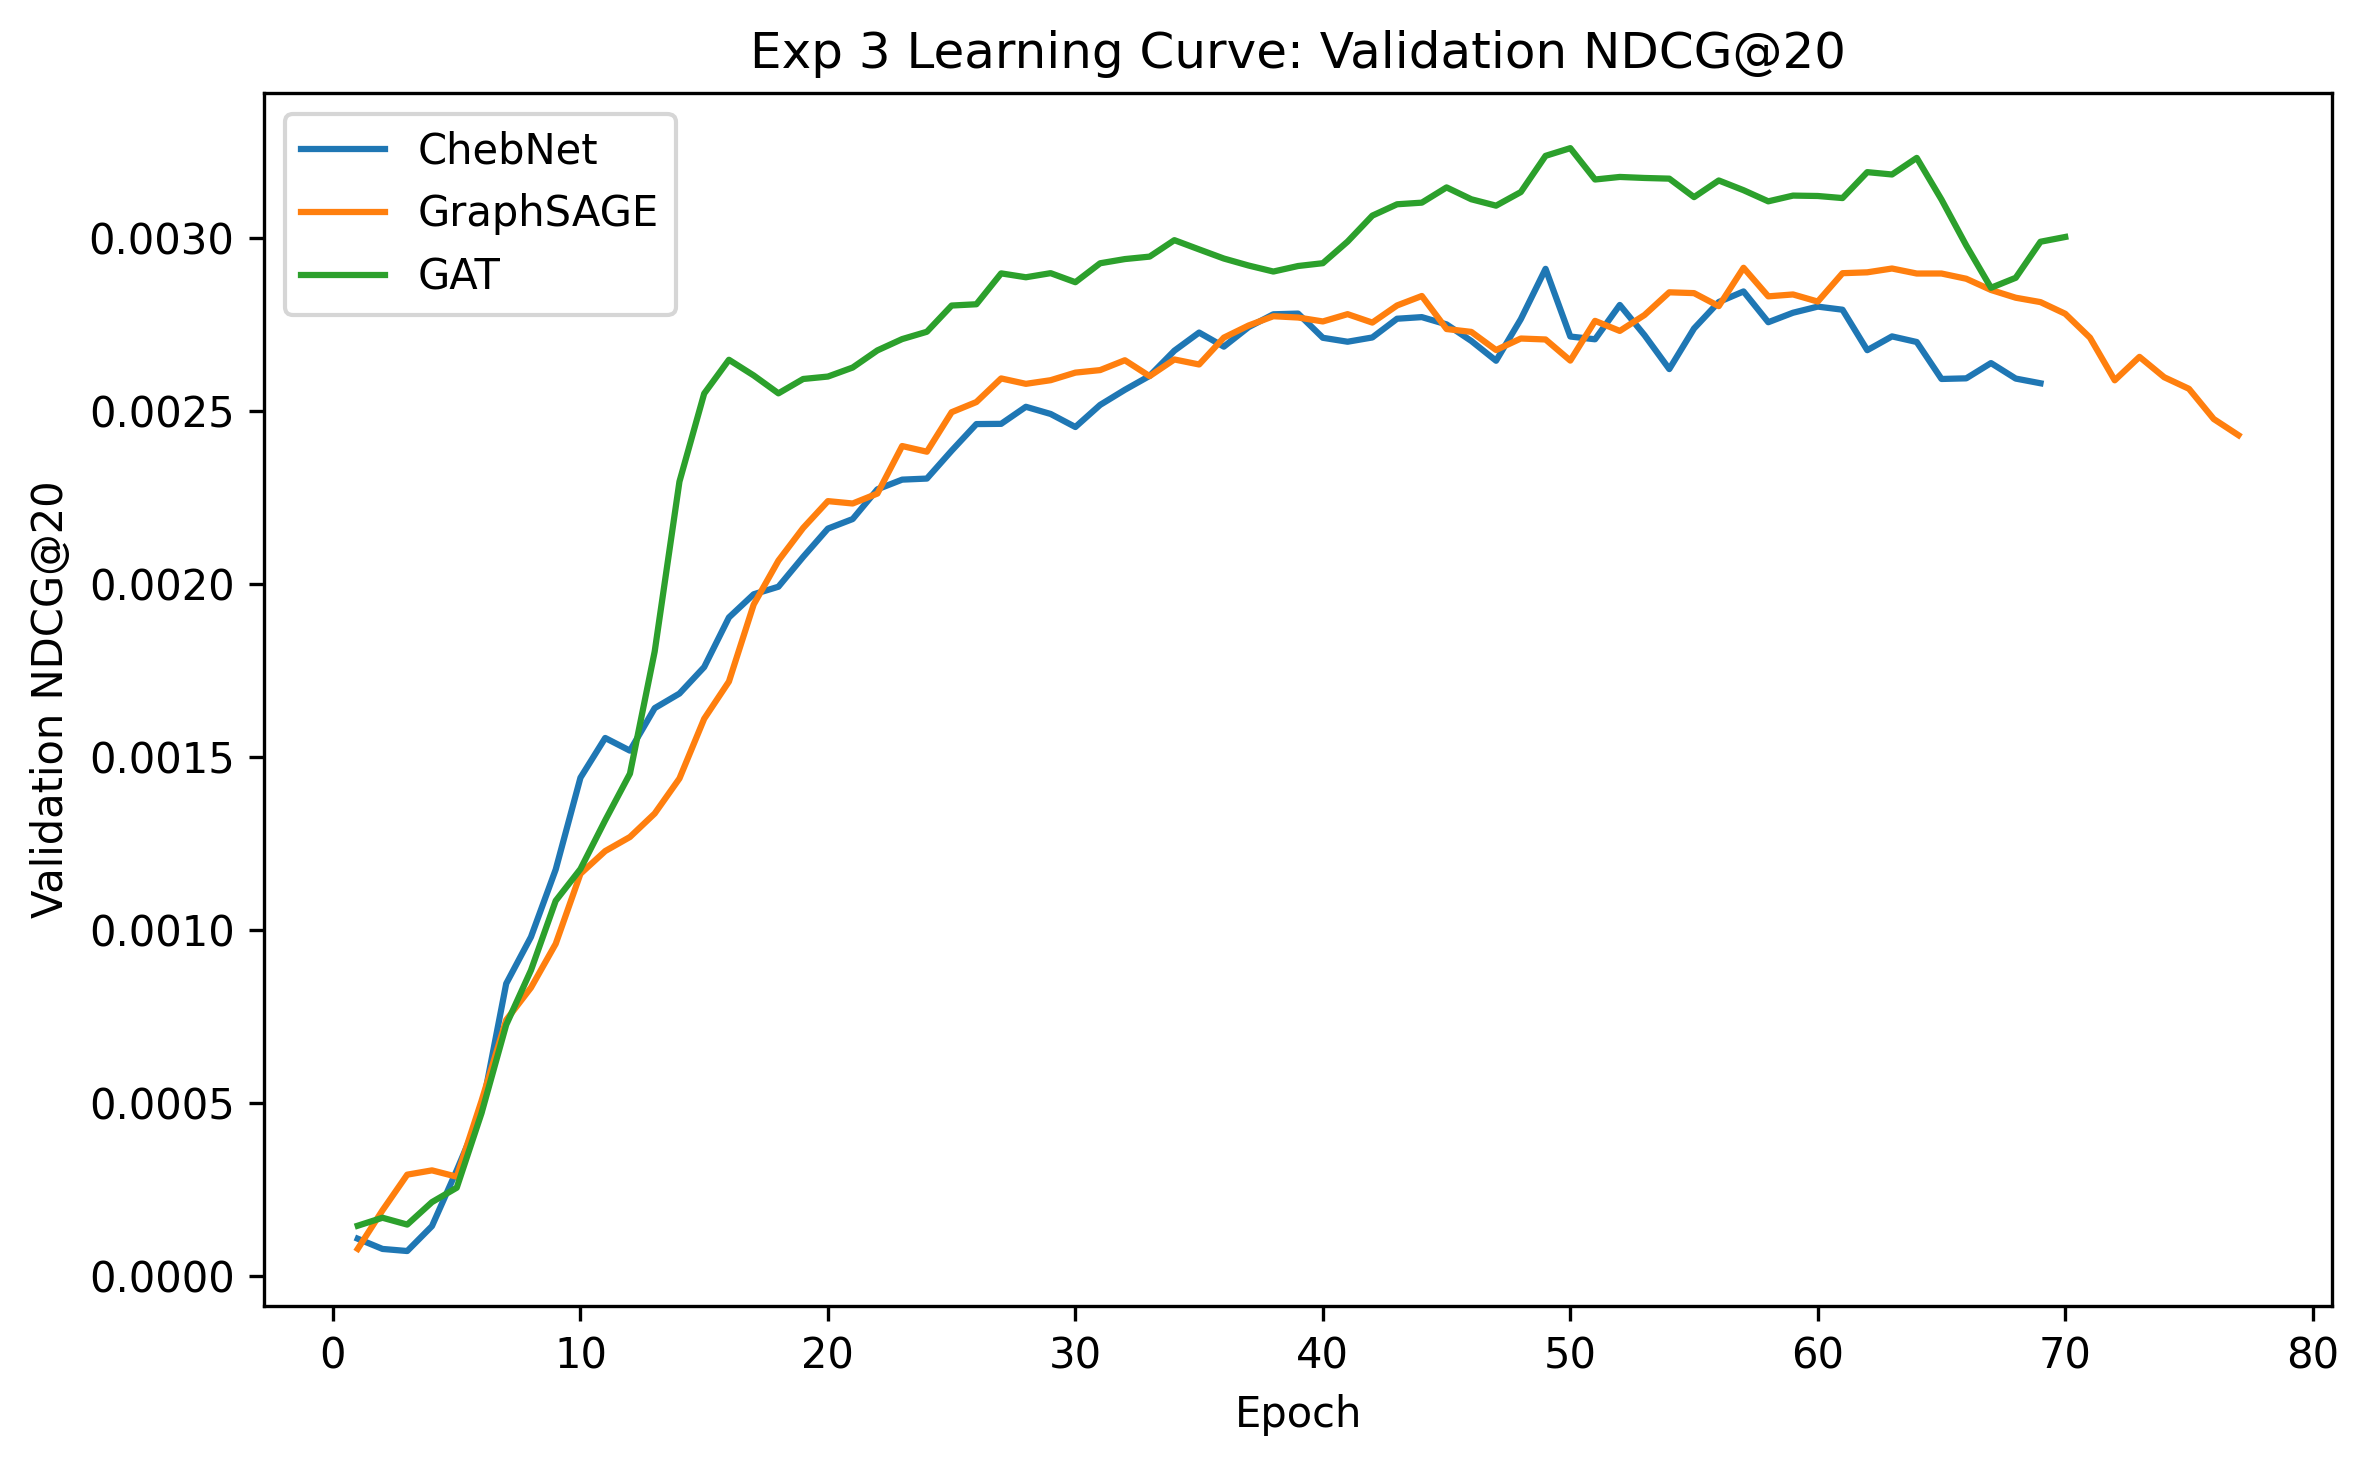

In [8]:
histories = {}

for item in RUNS:
    if not item['has_history']:
        continue

    label = item['label']
    run = item['run']
    hp = history_file(run)

    if hp is None:
        print(f'[WARN] missing history file for {label}: {run}')
        continue

    df = pd.read_csv(hp)
    histories[label] = df
    print(f'Loaded {label}: {hp.name}, shape={df.shape}')

if histories:
    fig, ax = plt.subplots(figsize=(8, 5))

    plotted = 0
    for label, df in histories.items():
        epoch_col = find_first_col(df.columns, [['epoch'], ['step']])
        if epoch_col is None:
            df = df.copy()
            df['epoch'] = range(1, len(df) + 1)
            epoch_col = 'epoch'

        ndcg_col = find_first_col(df.columns, [
            ['val', 'ndcg', '20'],
            ['valid', 'ndcg', '20'],
            ['validation', 'ndcg', '20'],
            ['val', 'ndcg'],
            ['ndcg', '20'],
        ])

        if ndcg_col is None:
            print(f'[WARN] {label}: no validation NDCG column found. Columns: {list(df.columns)}')
            continue

        ax.plot(df[epoch_col], df[ndcg_col], label=label)
        plotted += 1

    if plotted > 0:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation NDCG@20')
        ax.set_title('Exp 3 Learning Curve: Validation NDCG@20')
        ax.legend()
        fig.tight_layout()

        val_curve_path = FIG_DIR / 'exp3_learning_curve_val_ndcg20.png'
        fig.savefig(val_curve_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print('Saved:', val_curve_path)
        display(Image(str(val_curve_path)))
    else:
        plt.close(fig)
        print('[WARN] No validation NDCG curves were plotted.')
else:
    existing = FIG_DIR / 'exp3_learning_curve_val_ndcg20.png'
    if existing.exists():
        print('No history CSV loaded, displaying existing figure:', existing)
        display(Image(str(existing)))
    else:
        print('[WARN] No history CSV files and no existing validation NDCG figure found.')

## 5. Learning curve — Training loss

This regenerates `exp3_learning_curve_train_loss.png` when history CSV files are available, then displays it.

Saved: /content/drive/MyDrive/results/exp3_architecture/exp3_learning_curve_train_loss.png


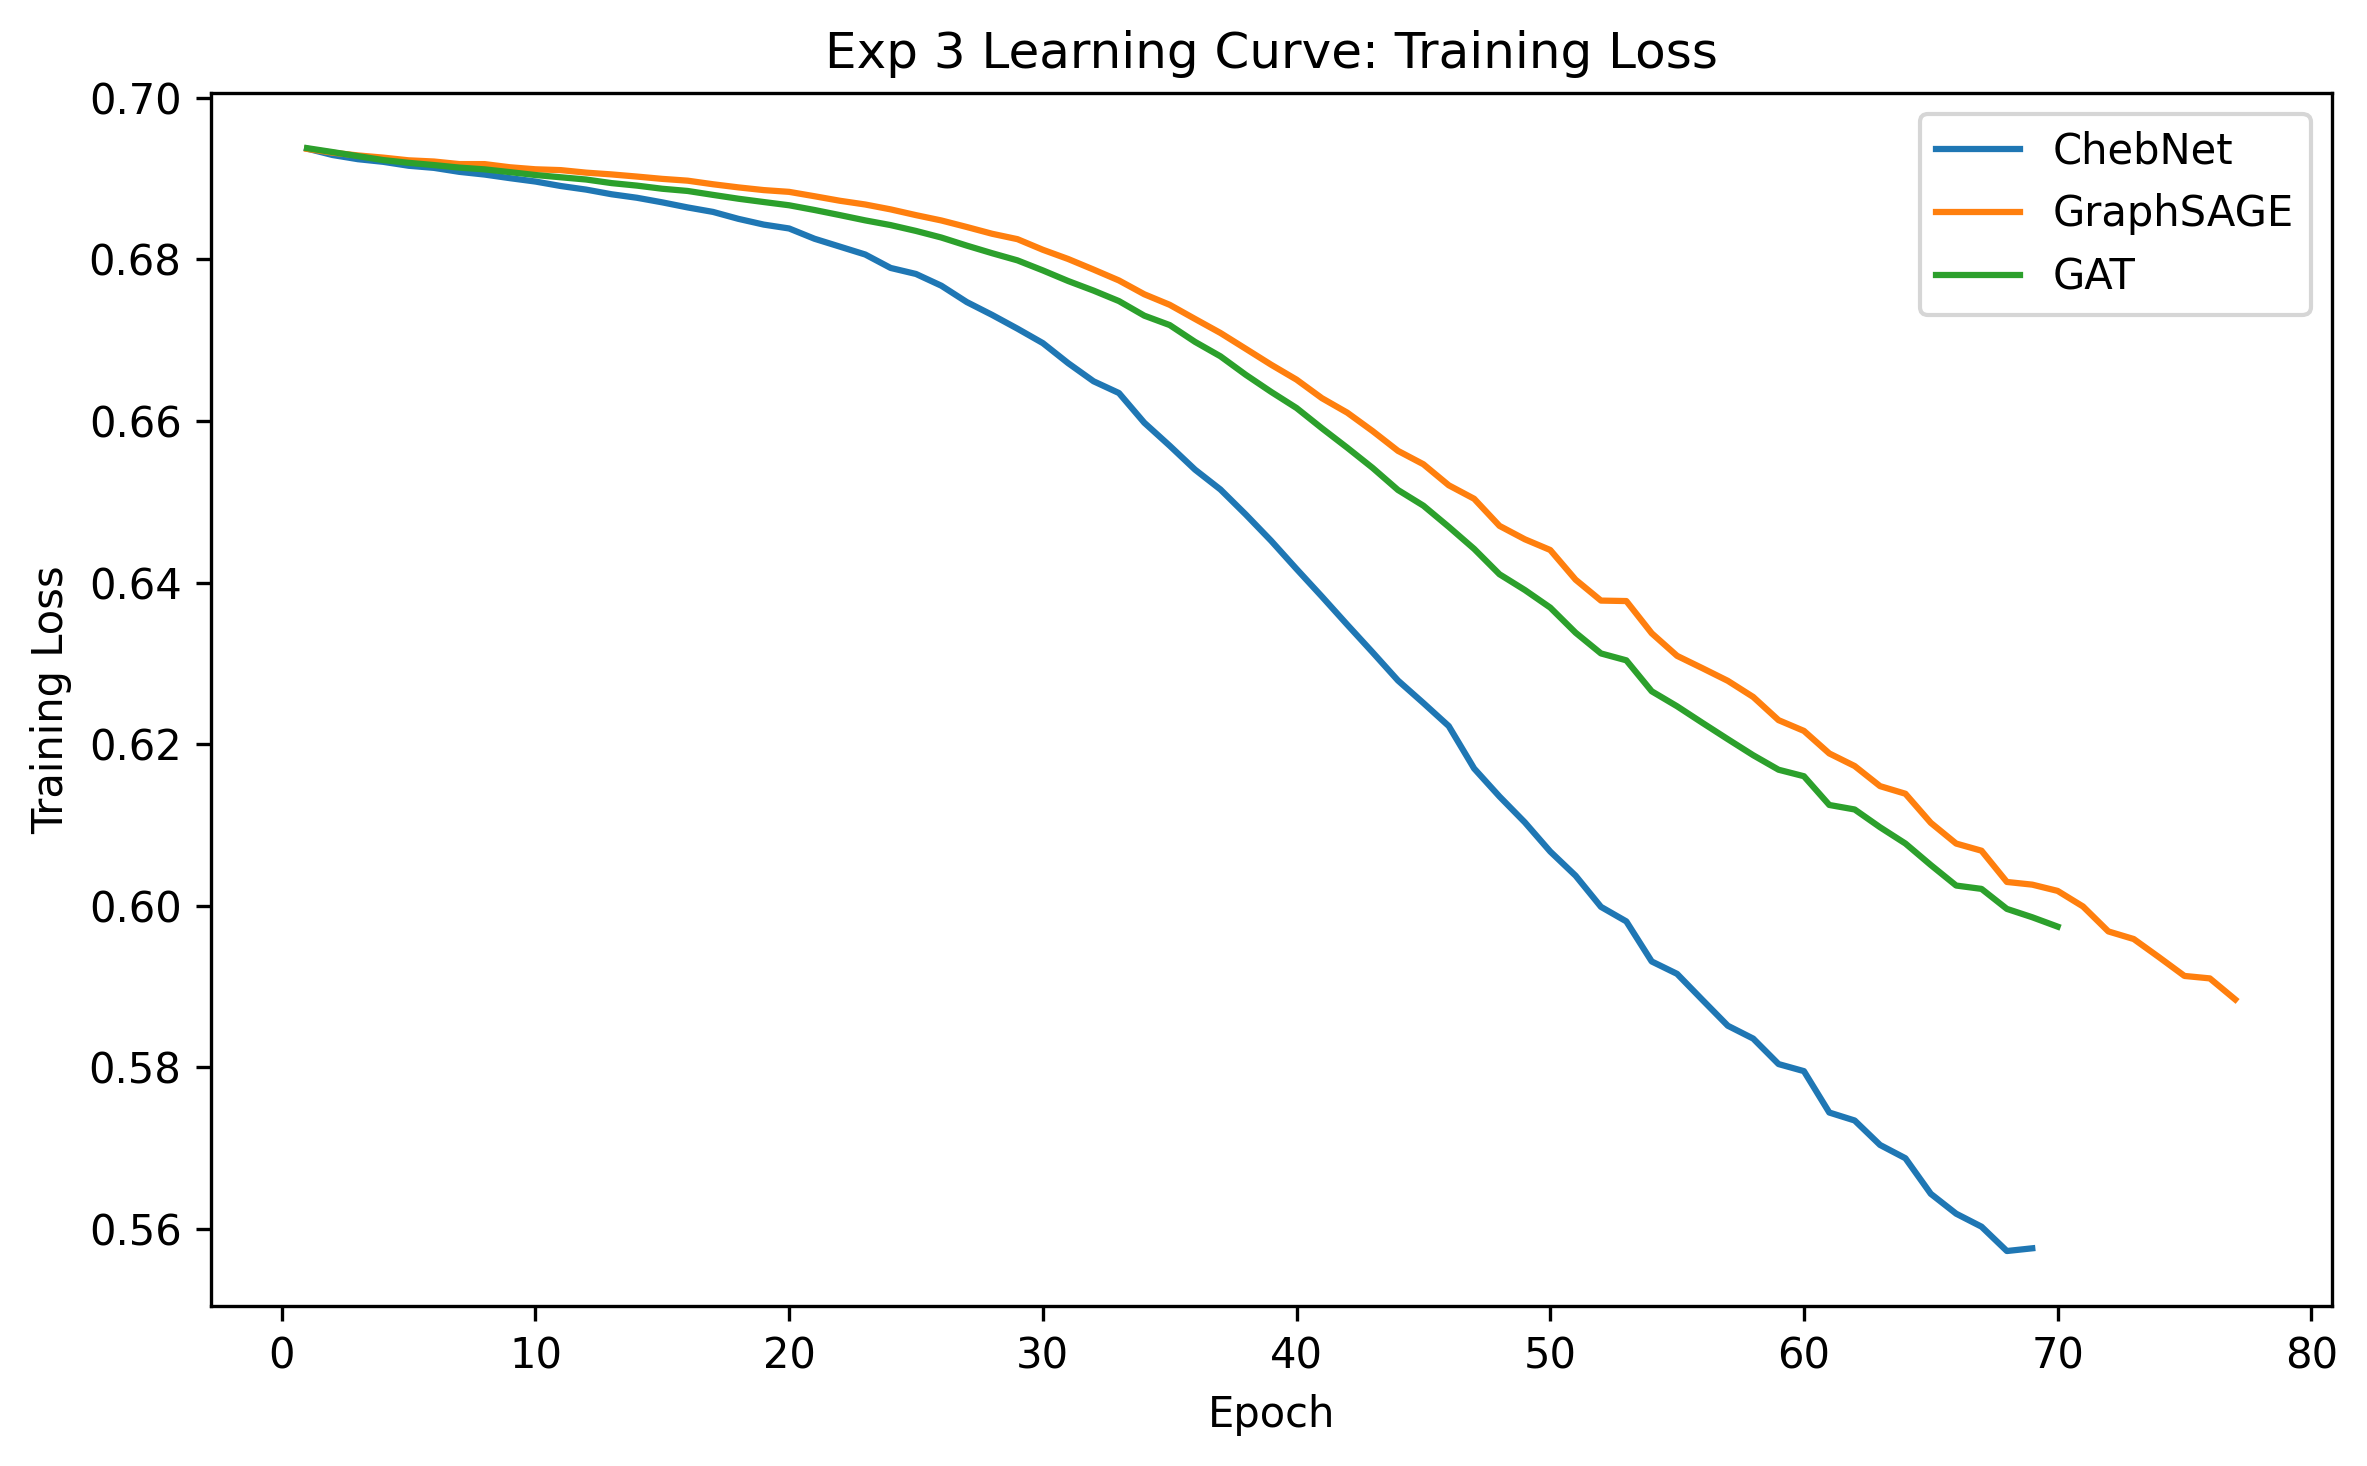

In [9]:
if histories:
    fig, ax = plt.subplots(figsize=(8, 5))

    plotted = 0
    for label, df in histories.items():
        epoch_col = find_first_col(df.columns, [['epoch'], ['step']])
        if epoch_col is None:
            df = df.copy()
            df['epoch'] = range(1, len(df) + 1)
            epoch_col = 'epoch'

        loss_col = find_first_col(df.columns, [
            ['bpr'],
            ['train', 'loss'],
            ['training', 'loss'],
            ['loss'],
        ])

        if loss_col is None:
            print(f'[WARN] {label}: no training loss column found. Columns: {list(df.columns)}')
            continue

        ax.plot(df[epoch_col], df[loss_col], label=label)
        plotted += 1

    if plotted > 0:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Training Loss')
        ax.set_title('Exp 3 Learning Curve: Training Loss')
        ax.legend()
        fig.tight_layout()

        loss_curve_path = FIG_DIR / 'exp3_learning_curve_train_loss.png'
        fig.savefig(loss_curve_path, dpi=300, bbox_inches='tight')
        plt.close(fig)

        print('Saved:', loss_curve_path)
        display(Image(str(loss_curve_path)))
    else:
        plt.close(fig)
        print('[WARN] No training-loss curves were plotted.')
else:
    existing = FIG_DIR / 'exp3_learning_curve_train_loss.png'
    if existing.exists():
        print('No history CSV loaded, displaying existing figure:', existing)
        display(Image(str(existing)))
    else:
        print('[WARN] No history CSV files and no existing training-loss figure found.')